MODELISATION EN PYTHON

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mlt
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
#Importer les données 
path=""
health=pd.read_csv(path+"healthcare_synthetic_data.csv", sep=",", header=0)

#On vérifie le contenu
health.head()



,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


J'ai enlevé le PID, jsp si il fallait mais le reste marchait pas sinon 

In [3]:
#transformation log pour valider l'hypothèse gaussienne
health["LogWeight_kg"] = np.log(health["Weight_kg"])
health["LogBMI"] = np.log(health["BMI"])
health["LogHeight_cm"] = np.log(health["Height_cm"])

health = health.drop(columns=["Weight_kg", "BMI", "Height_cm", "Patient_ID"])


On vérifie que c'est bien gaussien -> c'est très bizarre mais ok 

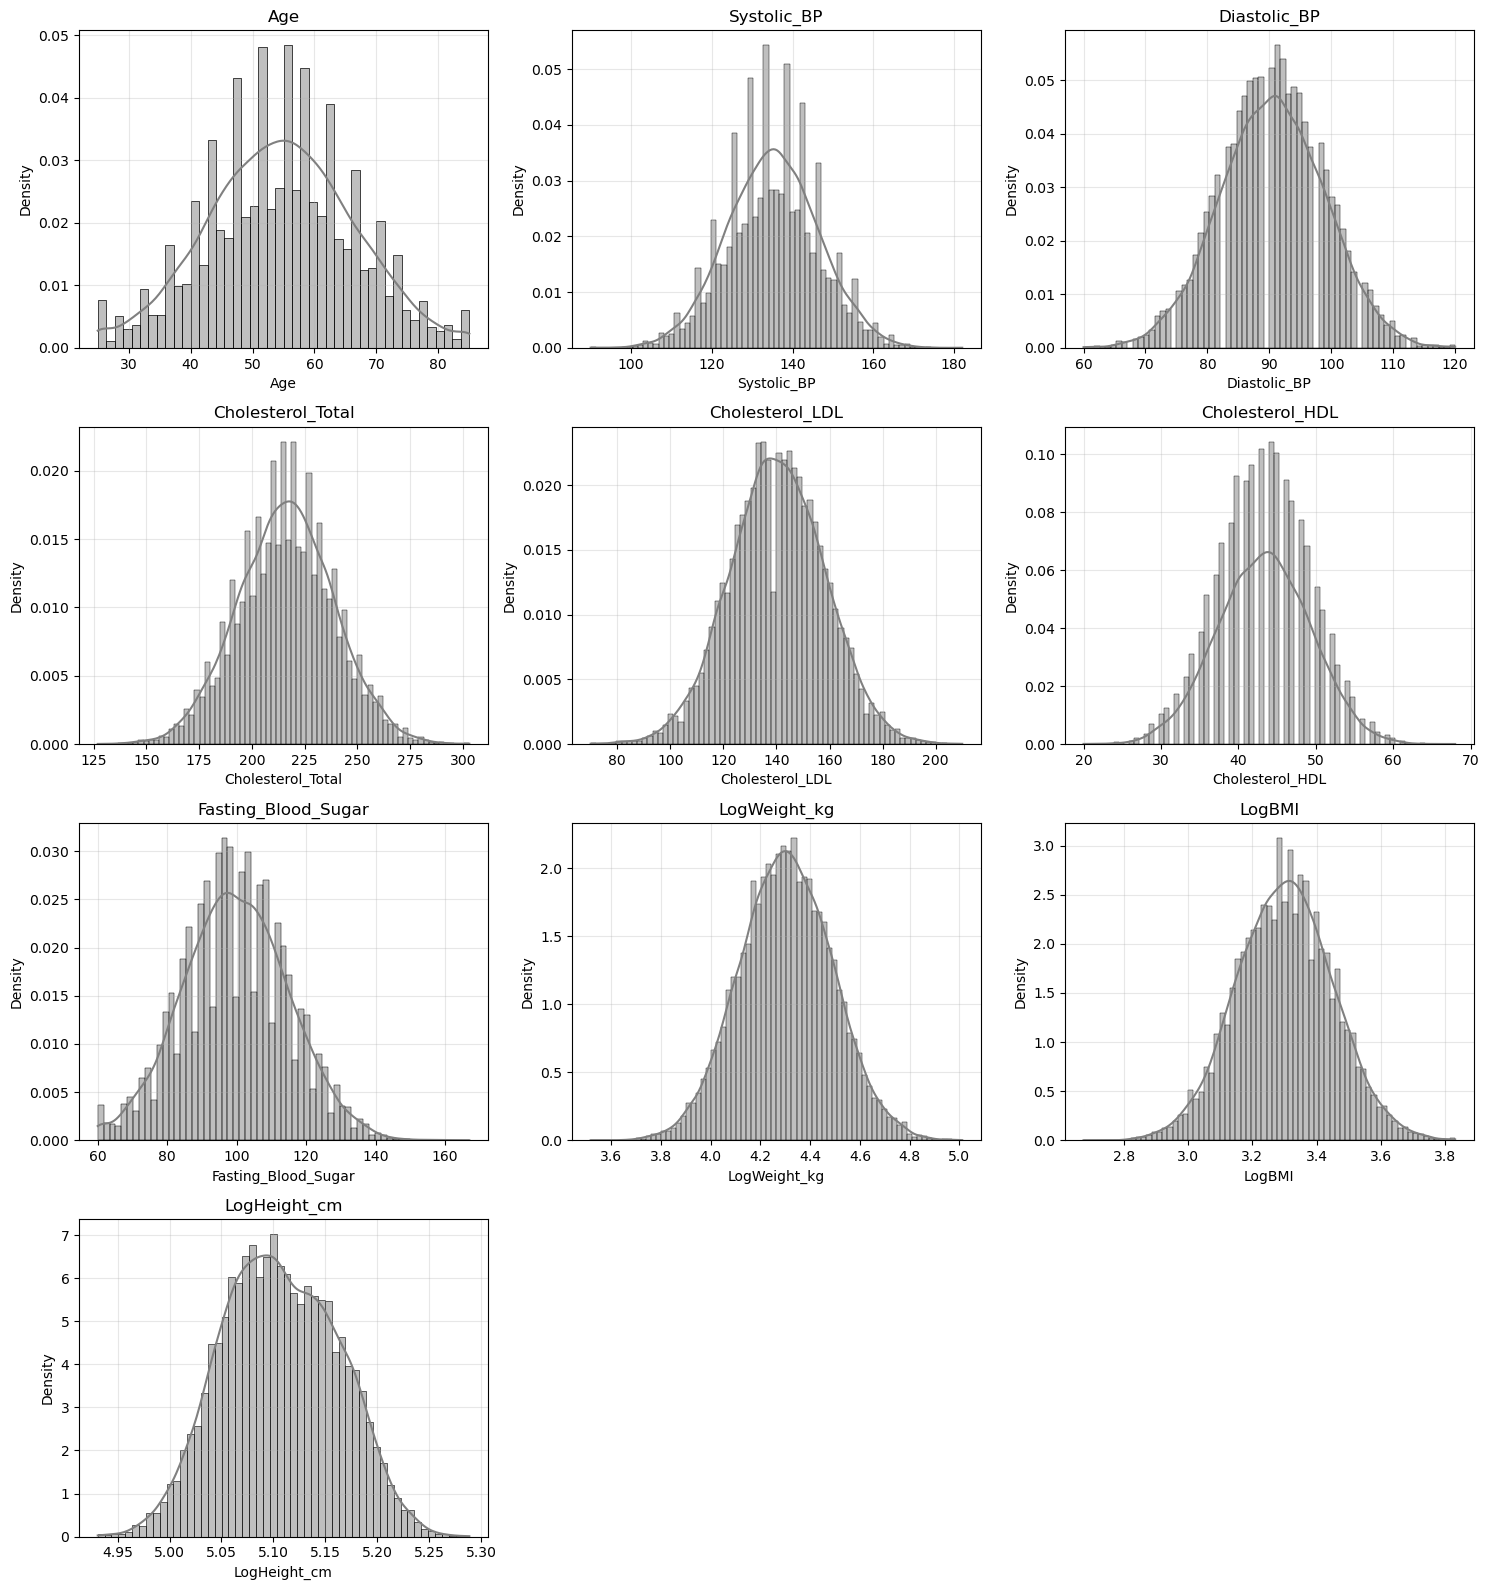

In [4]:

def plot_quantitative(df):
    # Sélectionner les colonnes numériques
    vars_num = df.select_dtypes(include=['number']).columns
    n_vars = len(vars_num)
    
    if n_vars == 0:
        print("Aucune variable numérique trouvée.")
        return

    # Calculer le nombre de lignes nécessaires pour 3 colonnes
    ncols = 3
    nrows = math.ceil(n_vars / ncols)

    # Créer la figure et les axes
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()  # Aplatir pour itérer facilement

    for i, col in enumerate(vars_num):
        # Création de l'histogramme + densité (kde)
        sns.histplot(df[col], kde=True, stat="density", 
                     color="grey", edgecolor="black", 
                     line_kws={"color": "blue"}, ax=axes[i])
        
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Density")
        axes[i].grid(True, alpha=0.3)

    # Supprimer les graphiques vides si n_vars n'est pas un multiple de 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

 # Transformation des variables catégorielles en type 'category'
 # on regarde seulement sur les quantitaties pour les histogrammes
cols_binaires = ['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Family_History', 'Heart_Disease_Risk','Stress_Level', 'Sleep_Hours','Physical_Activity_Level',] # liste de tes colonnes
health[cols_binaires] = health[cols_binaires].astype('category')
health_quanti = health.select_dtypes(include=['number'])
health_quali = health.select_dtypes(include=['category', 'object'])

plot_quantitative(health_quanti)

On split le data set

In [5]:
from sklearn.model_selection import train_test_split
health_train, health_test = train_test_split(health, test_size=0.2, train_size=0.8)
print(np.shape(health_train))
print(np.shape(health_test))


(12000, 18)
(3000, 18)


On normalise app c nécessaire pour les autres méthodes + plus propre. code pris du TP 

In [6]:
from sklearn.preprocessing import StandardScaler  #pris du TP 


scaler = StandardScaler()  
scaler.fit(health_train)  
health_train_norm = scaler.transform(health_train)  
# Meme transformation sur le test
health_test_norm = scaler.transform(health_test)

Cette étape est nécessaire car on veut tester la performance de nos algos, il est important que l'on teste nos modèles sur de nouvelles données pour être sûrs qu'il n'y a pas d'overfitting. 

MODELE LINEAIRE SANS PENALISATION / sans selection de variable


Maintenant, on enlève la colonne Heart_Disease_risk car c'est celle à prédire. est ce que ça aurait dû être fait avant ? Dans le TP c'est fait avant mais jsp si ça change quelque chose (vu qu'on a split avant ça garde le même ordre donc pas de pb d'après moi ??)

In [9]:
# 1. On isole la cible 
health_train_target = health_train["Heart_Disease_Risk"]

# 2. On crée 'health_train_features' en supprimant la colonne cible du dataset original
health_train_features = health_train.drop(columns=["Heart_Disease_Risk"])

# on fait pareil pour le test 
health_test_target = health_test["Heart_Disease_Risk"]
health_test_features = health_test.drop(columns=["Heart_Disease_Risk"])

In [ ]:
from sklearn.linear_model import LogisticRegression

method = LogisticRegression(solver='saga', penalty=None,max_iter=10000) # app le solveur liblinear ne peut pas avoir 0 de pénalité, on utilise donc saga
method.fit(health_train_features, health_train_target)
score_lin_sanspen=method.score(health_test_features, health_test_target)
ypred_lin_sanspen=method.predict(health_test_features)

print(f"Le score du modèle est : {score_lin_sanspen} et les prédictions sont : {ypred_lin_sanspen}")

Le score du modèle est : 0.7316666666666667 et les prédictions sont : [1 0 1 ... 0 1 0]


maintenant on visualise les faux positifs...

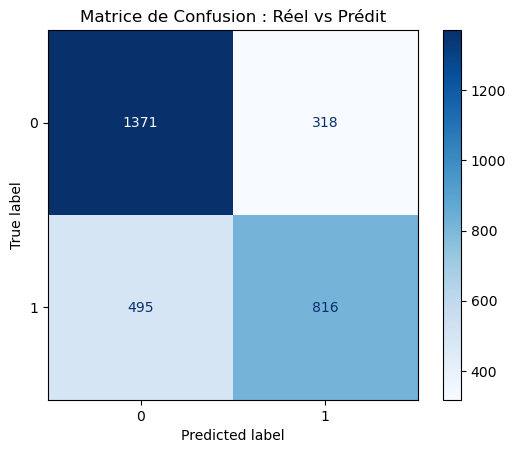

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Générer la matrice
cm = confusion_matrix(health_test_target, ypred_lin_sanspen)

# L'afficher de manière élégante
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=method.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion : Réel vs Prédit")
plt.show()

PENALISATION LASSO 

In [17]:
method = LogisticRegression(solver='saga', penalty='l1', max_iter=10000) #app L1 c'est lasso 
method.fit(health_train_features, health_train_target)
score_lin_lasso=method.score(health_test_features, health_test_target)
ypred_lin_lasso=method.predict(health_test_features)

print(f"Le score du modèle est : {score_lin_lasso} et les prédictions sont : {ypred_lin_lasso}")

Le score du modèle est : 0.7316666666666667 et les prédictions sont : [1 0 1 ... 0 1 0]


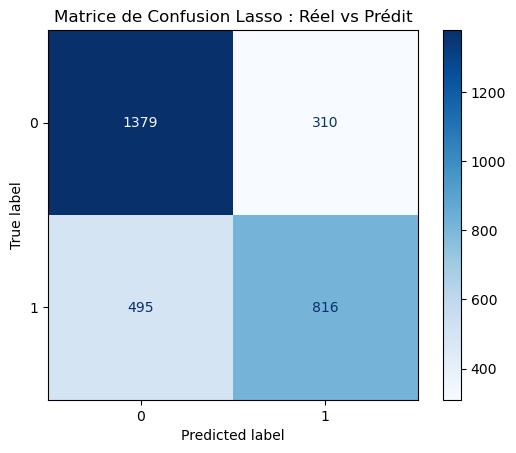

In [18]:
# Générer la matrice
cm = confusion_matrix(health_test_target, ypred_lin_lasso)

# L'afficher de manière élégante
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=method.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion Lasso : Réel vs Prédit")
plt.show()